# Fictalent · Auditoria de qualidade · treinamento e SST, obrigação legal com data de validade
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar os dois módulos de documento com prazo: cursos, turmas, participantes e certificados; exames (ASO), programas legais, riscos do posto, acidentes e CAT. O valor deles no BI é o alerta, e o cliente declarou o defeito que mais o preocupa: pessoa alocada com ASO vencido, sem ninguém avisar. Entra como hipótese, medida como prevalência no último dia de cada mês.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `treinamento e sst`: `curso`, `curso_funcao`, `turma`, `turma_participante`, `certificado`, `tipo_exame`, `aso`, `programa_sst`, `risco_posto`, `acidente`, `cat`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. Há pessoas alocadas com ASO vencido, ou sem ASO admissional? Quantas, em que meses? (declaração)
2. A validade dos certificados e dos exames bate com o que o curso e o tipo de exame determinam?
3. Turma, participante, certificado, acidente, afastamento e CAT contam a mesma história na mesma ordem?
4. Os cursos obrigatórios por função estão cobertos para quem está em campo?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude e coerência](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [Validade derivada e faixas](#secao-7)
8. [Cronologia](#secao-8)
9. [Integridade referencial](#secao-9)
10. [A declaração: ASO vencido com pessoa alocada](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("treinamento")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("treinamento")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

5 tabelas do domínio: curso, curso_funcao, turma, turma_participante, certificado


In [3]:
# dois módulos num notebook só: a lista de tabelas é a união
tabelas = esquema.do_modulo("treinamento") + esquema.do_modulo("sst")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("treinamento_sst")
print(f"{len(tabelas)} tabelas: {', '.join(t.qualificado for t in tabelas)}")

11 tabelas: treinamento.curso, treinamento.curso_funcao, treinamento.turma, treinamento.turma_participante, treinamento.certificado, sst.tipo_exame, sst.aso, sst.programa_sst, sst.risco_posto, sst.acidente, sst.cat


## Nota Técnica

**Observado:** dois módulos num notebook só, porque têm a mesma natureza (documento com prazo): as 5 tabelas de `treinamento` e as 6 de `sst`, lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [4]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 86.338


,tabela,linhas_vivas,marca
0,treinamento.curso,11,2026-09-24 15:02:06.227515
1,treinamento.curso_funcao,104,2026-09-24 15:02:06.227515
2,treinamento.turma,5411,2026-09-24 15:02:06.227515
3,treinamento.turma_participante,29424,2026-09-24 15:02:06.227515
4,treinamento.certificado,29190,2026-09-24 15:02:06.227515
5,sst.tipo_exame,5,2026-09-24 15:02:06.227515
6,sst.aso,20402,2026-09-24 15:02:06.227515
7,sst.programa_sst,541,2026-09-24 15:02:06.227515
8,sst.risco_posto,1064,2026-09-24 15:02:06.227515
9,sst.acidente,87,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 86.338 linhas vivas: 5.411 turmas com 29.424 participantes e 29.190 certificados; 20.402 exames (16.992 admissionais), 541 programas legais, 1.064 riscos de posto, 87 acidentes e 99 CATs.

**Por que importa:** o valor destes módulos no BI é o alerta: documento vencido com pessoa em campo é risco jurídico imediato para a Fictalent e para o cliente.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [5]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

90 colunas em 11 tabelas
Colunas com um valor só: 6 (treinamento.curso.criado_em, treinamento.curso.atualizado_em, treinamento.curso_funcao.criado_em, treinamento.curso_funcao.atualizado_em, sst.tipo_exame.criado_em, sst.tipo_exame.atualizado_em)
Colunas totalmente vazias: 0


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,treinamento.curso,id,BIGINT,0,0.00,12,1,11
1,treinamento.curso,codigo,VARCHAR,0,0.00,11,ATEND,NR35
2,treinamento.curso,nome,VARCHAR,0,0.00,12,Atendimento ao cliente,NR-35 Trabalho em altura
3,treinamento.curso,tipo,VARCHAR,0,0.00,3,COMPORTAMENTAL,TECNICO
4,treinamento.curso,carga_horaria,"DECIMAL(5,1)",0,0.00,6,2.0,40.0
5,treinamento.curso,validade_meses,BIGINT,4,36.36,2,12,24
6,treinamento.curso,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:02:00,2018-01-02 08:02:00
7,treinamento.curso,atualizado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:02:00,2018-01-02 08:02:00
8,treinamento.curso_funcao,id,BIGINT,0,0.00,100,1,104
9,treinamento.curso_funcao,curso_id,BIGINT,0,0.00,12,1,11


In [6]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

90 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 90 colunas, tipos compatíveis com a DDL; só os carimbos dos três catálogos (curso, curso por função, tipo de exame) são constantes.

**Por que importa:** o perfil aponta para as datas de validade, que são o assunto das seções 7 e 10.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude e coerência

Certificado só para aprovado; participante com contrato vigente na turma; ASO demissional sem validade (por regra) e os demais com validade; acidente com afastamento quando há dias afastados; CAT para todo acidente grave ou com afastamento.

In [7]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 8; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
17,treinamento.turma,cliente_id,BIGINT,5392,99.65,False
42,sst.tipo_exame,periodicidade_meses,BIGINT,4,80.00,False
22,treinamento.turma,fornecedor_id,BIGINT,3150,58.21,False
37,treinamento.certificado,dt_validade,DATE,15304,52.43,False
30,treinamento.turma_participante,nota,"DECIMAL(4,1)",15316,52.05,False
5,treinamento.curso,validade_meses,BIGINT,4,36.36,False
80,sst.acidente,afastamento_id,BIGINT,13,14.94,False
49,sst.aso,dt_validade,DATE,2505,12.28,False


In [8]:
coerencia = consulta.sql(con, '''
    SELECT 'certificado de participante nao aprovado' AS caso, count(*) AS linhas FROM treinamento.certificado c JOIN treinamento.turma_participante p ON p.id = c.turma_participante_id WHERE c.excluido_em IS NULL AND NOT p.fl_aprovado
    UNION ALL SELECT 'participante aprovado sem certificado', count(*) FROM treinamento.turma_participante p WHERE p.excluido_em IS NULL AND p.fl_aprovado AND NOT EXISTS (SELECT 1 FROM treinamento.certificado c WHERE c.excluido_em IS NULL AND c.turma_participante_id = p.id)
    UNION ALL SELECT 'participante aprovado com presenca < 75%', count(*) FROM treinamento.turma_participante WHERE excluido_em IS NULL AND fl_aprovado AND presenca_pct < 75
    UNION ALL SELECT 'participante sem contrato vigente na data da turma', count(*) FROM treinamento.turma_participante p JOIN treinamento.turma t ON t.id = p.turma_id WHERE p.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = p.colaborador_id AND t.dt_inicio BETWEEN k.dt_admissao AND coalesce(k.dt_rescisao, DATE '9999-12-31'))
    UNION ALL SELECT 'turma sem participante', count(*) FROM treinamento.turma t WHERE t.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM treinamento.turma_participante p WHERE p.excluido_em IS NULL AND p.turma_id = t.id)
    UNION ALL SELECT 'turma com fornecedor de tipo diferente de TREINAMENTO', count(*) FROM treinamento.turma t JOIN financeiro.fornecedor f ON f.id = t.fornecedor_id WHERE t.excluido_em IS NULL AND f.tipo <> 'TREINAMENTO'
    UNION ALL SELECT 'curso NR sem validade_meses', count(*) FROM treinamento.curso WHERE excluido_em IS NULL AND tipo = 'NR' AND validade_meses IS NULL
    UNION ALL SELECT 'certificado sem validade de curso que tem validade', count(*) FROM treinamento.certificado c JOIN treinamento.turma_participante p ON p.id = c.turma_participante_id JOIN treinamento.turma t ON t.id = p.turma_id JOIN treinamento.curso u ON u.id = t.curso_id WHERE c.excluido_em IS NULL AND u.validade_meses IS NOT NULL AND c.dt_validade IS NULL
    UNION ALL SELECT 'ASO DEMISSIONAL com validade', count(*) FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo = 'DEMISSIONAL' AND a.dt_validade IS NOT NULL
    UNION ALL SELECT 'ASO nao DEMISSIONAL sem validade', count(*) FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo <> 'DEMISSIONAL' AND a.dt_validade IS NULL
    UNION ALL SELECT 'ASO com fornecedor de tipo diferente de EXAMES', count(*) FROM sst.aso a JOIN financeiro.fornecedor f ON f.id = a.fornecedor_id WHERE a.excluido_em IS NULL AND f.tipo <> 'EXAMES'
    UNION ALL SELECT 'ASO de pessoa sem contrato na data do exame (com folga de 30 dias)', count(*) FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo <> 'ADMISSIONAL' AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = a.colaborador_id AND a.dt_exame BETWEEN k.dt_admissao - INTERVAL 30 DAY AND coalesce(k.dt_rescisao, DATE '9999-12-31') + INTERVAL 30 DAY)
    UNION ALL SELECT 'acidente com dias_afastamento > 0 sem afastamento', count(*) FROM sst.acidente WHERE excluido_em IS NULL AND dias_afastamento > 0 AND afastamento_id IS NULL
    UNION ALL SELECT 'acidente com afastamento que nao e do tipo ACIDENTE', count(*) FROM sst.acidente a JOIN pessoas.afastamento f ON f.id = a.afastamento_id WHERE a.excluido_em IS NULL AND f.tipo <> 'ACIDENTE'
    UNION ALL SELECT 'acidente com afastamento de outra pessoa', count(*) FROM sst.acidente a JOIN pessoas.afastamento f ON f.id = a.afastamento_id WHERE a.excluido_em IS NULL AND f.colaborador_id <> a.colaborador_id
    UNION ALL SELECT 'acidente GRAVE/FATAL sem CAT', count(*) FROM sst.acidente a WHERE a.excluido_em IS NULL AND a.gravidade IN ('GRAVE', 'FATAL') AND NOT EXISTS (SELECT 1 FROM sst.cat c WHERE c.excluido_em IS NULL AND c.acidente_id = a.id)
    UNION ALL SELECT 'acidente com afastamento sem CAT', count(*) FROM sst.acidente a WHERE a.excluido_em IS NULL AND a.dias_afastamento > 0 AND NOT EXISTS (SELECT 1 FROM sst.cat c WHERE c.excluido_em IS NULL AND c.acidente_id = a.id)
    UNION ALL SELECT 'CAT OBITO em acidente nao FATAL', count(*) FROM sst.cat c JOIN sst.acidente a ON a.id = c.acidente_id WHERE c.excluido_em IS NULL AND c.tipo_cat = 'OBITO' AND a.gravidade <> 'FATAL'
    UNION ALL SELECT 'programa_sst de contrato que nao e do cliente', count(*) FROM sst.programa_sst p JOIN comercial.contrato k ON k.id = p.contrato_id WHERE p.excluido_em IS NULL AND k.cliente_id <> p.cliente_id
    UNION ALL SELECT 'risco_posto de programa de outro contrato', count(*) FROM sst.risco_posto r JOIN sst.programa_sst p ON p.id = r.programa_sst_id JOIN comercial.posto o ON o.id = r.posto_id WHERE r.excluido_em IS NULL AND p.contrato_id IS NOT NULL AND p.contrato_id <> o.contrato_id
''')
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))

Testes de coerência: 20; com linhas: 0
                                                              caso  linhas
                          certificado de participante nao aprovado       0
                             participante aprovado sem certificado       0
                          participante aprovado com presenca < 75%       0
                participante sem contrato vigente na data da turma       0
                                            turma sem participante       0
             turma com fornecedor de tipo diferente de TREINAMENTO       0
                                       curso NR sem validade_meses       0
                certificado sem validade de curso que tem validade       0
                                      ASO DEMISSIONAL com validade       0
                                  ASO nao DEMISSIONAL sem validade       0
                    ASO com fornecedor de tipo diferente de EXAMES       0
ASO de pessoa sem contrato na data do exame (com folga de 30 

## Nota Técnica

**Observado:** 8 colunas com nulo, nenhuma `NOT NULL`, e os 20 testes de coerência passaram: certificado só de aprovado e todo aprovado tem certificado; presença mínima respeitada; participante sempre com contrato vigente; exame demissional sem validade e os demais com validade; fornecedor do tipo certo; acidente com afastamento sempre do tipo acidente e da mesma pessoa; todo acidente grave, fatal ou com afastamento tem CAT; programa e risco sempre do contrato certo.

**Por que importa:** a relação entre acidente, afastamento e CAT é a que a fiscalização olha primeiro, e está íntegra.

**Ação:** nenhuma.

<a id="secao-5"></a>

# 5. Unicidade

Código de curso, curso por função, participante por turma, certificado por participante e número de certificado e de CAT são `UNIQUE`. Conteúdo: o mesmo exame duas vezes no mesmo dia, o mesmo risco duas vezes no posto, o mesmo acidente duas vezes, a mesma turma duas vezes.

In [9]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
print()
resultado = {}
for tabela, colunas, descricao in (
    ("sst.aso", ["colaborador_id", "tipo_exame_id", "dt_exame"], "o mesmo exame duas vezes no dia"),
    ("sst.risco_posto", ["posto_id", "agente_risco"], "o mesmo agente de risco duas vezes no posto"),
    ("sst.acidente", ["colaborador_id", "dt_acidente"], "dois acidentes da mesma pessoa no mesmo dia"),
    ("treinamento.turma", ["curso_id", "filial_id", "dt_inicio"], "a mesma turma aberta duas vezes"),
):
    grupos, envolvidas = checagens.repetidos(con, tabela, colunas)
    resultado[tabela] = (grupos, envolvidas)
    print(f"{tabela:<24} {'+'.join(colunas):<40} {grupos:>5} grupos  {envolvidas:>6} linhas   ({descricao})")
n_turmas = checagens.linhas(con, "treinamento.turma")
registro.anotar(
    secao="5", tabela="treinamento.turma", coluna="curso_id, filial_id, dt_inicio",
    achado="turmas do mesmo curso, na mesma filial, começando no mesmo dia: paralelas legítimas ou cadastro em duplicidade", linhas=resultado["treinamento.turma"][1], total=n_turmas, severidade="baixa",
    impacto="turma duplicada dobra o custo de treinamento no rateio e o número de treinados no indicador",
    acao="confirmar com o cliente; marcar, não fundir",
)

7 chaves UNIQUE conferidas; com repetição: 0
                        tabela                    chave  grupos_repetidos  linhas
             treinamento.curso                   codigo                 0       0
      treinamento.curso_funcao      curso_id, funcao_id                 0       0
treinamento.turma_participante turma_id, colaborador_id                 0       0
       treinamento.certificado    turma_participante_id                 0       0
       treinamento.certificado                   numero                 0       0
                sst.tipo_exame                   codigo                 0       0
                       sst.cat                   numero                 0       0

sst.aso                  colaborador_id+tipo_exame_id+dt_exame        0 grupos       0 linhas   (o mesmo exame duas vezes no dia)
sst.risco_posto          posto_id+agente_risco                        0 grupos       0 linhas   (o mesmo agente de risco duas vezes no posto)
sst.acidente             c

Achado(dominio='treinamento_sst', secao='5', tabela='treinamento.turma', coluna='curso_id, filial_id, dt_inicio', achado='turmas do mesmo curso, na mesma filial, começando no mesmo dia: paralelas legítimas ou cadastro em duplicidade', linhas=192, total=5411, severidade='baixa', impacto='turma duplicada dobra o custo de treinamento no rateio e o número de treinados no indicador', acao='confirmar com o cliente; marcar, não fundir', declaracao='')

## Nota Técnica

**Observado:** as 7 chaves `UNIQUE` íntegras; nenhum exame, risco ou acidente duplicado por conteúdo. A única repetição: 90 grupos de turmas do mesmo curso, na mesma filial, começando no mesmo dia (192 turmas), que podem ser turmas paralelas legítimas ou a mesma turma cadastrada duas vezes.

**Por que importa:** turma duplicada dobra o custo de treinamento no rateio e o número de treinados no indicador.

**Ação:** anotar como achado de severidade baixa: confirmar com o cliente; marcar, não fundir.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK`, a distribuição, e a periodicidade de cada tipo de exame, que é o que permite derivar a validade.

In [10]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
for tabela, coluna in (("treinamento.curso", "tipo"), ("sst.aso", "resultado"), ("sst.programa_sst", "tipo"), ("sst.risco_posto", "grau"), ("sst.acidente", "tipo"), ("sst.acidente", "gravidade"), ("sst.cat", "tipo_cat")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT {coluna}, count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))
print(consulta.sql(con, "SELECT e.codigo, e.periodicidade_meses, count(a.id) AS exames FROM sst.tipo_exame e LEFT JOIN sst.aso a ON a.tipo_exame_id = e.id AND a.excluido_em IS NULL WHERE e.excluido_em IS NULL GROUP BY 1, 2 ORDER BY 3 DESC").to_string(index=False))

8 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,treinamento.curso,tipo,3,0,
1,sst.tipo_exame,codigo,5,0,
2,sst.aso,resultado,3,0,
3,sst.programa_sst,tipo,3,0,
4,sst.risco_posto,grau,3,0,
5,sst.acidente,tipo,3,0,
6,sst.acidente,gravidade,4,0,
7,sst.cat,tipo_cat,3,0,


treinamento.curso.tipo: NR=5, COMPORTAMENTAL=3, TECNICO=3
sst.aso.resultado: APTO=19809, APTO_RESTRICAO=593
sst.programa_sst.tipo: PCMSO=297, PGR=177, LTCAT=67
sst.risco_posto.grau: MEDIO=598, BAIXO=419, ALTO=47
sst.acidente.tipo: TIPICO=77, TRAJETO=10
sst.acidente.gravidade: MODERADA=44, LEVE=35, GRAVE=8
sst.cat.tipo_cat: INICIAL=87, REABERTURA=12
        codigo  periodicidade_meses  exames
   ADMISSIONAL                 <NA>   16992
   DEMISSIONAL                 <NA>    2505
     PERIODICO                   12     770
       RETORNO                 <NA>     135
MUDANCA_FUNCAO                 <NA>       0


## Nota Técnica

**Observado:** os 8 domínios só têm valores previstos. Só o exame periódico tem periodicidade (12 meses); os demais tipos têm validade dada exame a exame.

**Por que importa:** a periodicidade no catálogo é o que permite derivar a validade e conferi-la (seção 7).

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. Validade derivada e faixas

A validade do certificado é a emissão mais a validade do curso; a do exame periódico é o exame mais a periodicidade do tipo. Presença entre 0 e 100, nota entre 0 e 10, carga horária e custo positivos, dias de afastamento coerentes com o afastamento.

In [11]:
faixas = consulta.sql(con, '''
    SELECT 'certificado: validade <> emissao + validade do curso (tolerancia 1 dia)' AS caso, count(*) AS linhas
      FROM treinamento.certificado c JOIN treinamento.turma_participante p ON p.id = c.turma_participante_id JOIN treinamento.turma t ON t.id = p.turma_id JOIN treinamento.curso u ON u.id = t.curso_id
     WHERE c.excluido_em IS NULL AND u.validade_meses IS NOT NULL AND c.dt_validade IS NOT NULL AND abs(date_diff('day', c.dt_emissao + to_months(u.validade_meses), c.dt_validade)) > 1
    UNION ALL SELECT 'ASO: validade <> exame + periodicidade do tipo (tolerancia 1 dia)', count(*)
      FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id
     WHERE a.excluido_em IS NULL AND e.periodicidade_meses IS NOT NULL AND a.dt_validade IS NOT NULL AND abs(date_diff('day', a.dt_exame + to_months(e.periodicidade_meses), a.dt_validade)) > 1
    UNION ALL SELECT 'participante: presenca fora de 0..100', count(*) FROM treinamento.turma_participante WHERE excluido_em IS NULL AND (presenca_pct < 0 OR presenca_pct > 100)
    UNION ALL SELECT 'participante: nota fora de 0..10', count(*) FROM treinamento.turma_participante WHERE excluido_em IS NULL AND nota IS NOT NULL AND (nota < 0 OR nota > 10)
    UNION ALL SELECT 'curso: carga_horaria <= 0', count(*) FROM treinamento.curso WHERE excluido_em IS NULL AND carga_horaria <= 0
    UNION ALL SELECT 'turma: custo_total < 0', count(*) FROM treinamento.turma WHERE excluido_em IS NULL AND custo_total < 0
    UNION ALL SELECT 'risco_posto: insalubridade fora de 0..40%', count(*) FROM sst.risco_posto WHERE excluido_em IS NULL AND (insalubridade_pct < 0 OR insalubridade_pct > 0.40)
    UNION ALL SELECT 'acidente: dias_afastamento < 0', count(*) FROM sst.acidente WHERE excluido_em IS NULL AND dias_afastamento < 0
    UNION ALL SELECT 'acidente: dias_afastamento diferente do afastamento ligado (tolerancia 1 dia)', count(*) FROM sst.acidente a JOIN pessoas.afastamento f ON f.id = a.afastamento_id WHERE a.excluido_em IS NULL AND f.dt_fim IS NOT NULL AND abs(date_diff('day', f.dt_inicio, f.dt_fim) + 1 - a.dias_afastamento) > 1
    UNION ALL SELECT 'acidente FATAL com dias_afastamento > 0', count(*) FROM sst.acidente WHERE excluido_em IS NULL AND gravidade = 'FATAL' AND dias_afastamento > 0
''')
print(f"Regras conferidas: {len(faixas)}; com linhas: {int((faixas['linhas'] > 0).sum())}")
print(faixas.to_string(index=False))
n_certificados = checagens.linhas(con, "treinamento.certificado")
registro.anotar(
    secao="7", tabela="treinamento.certificado", coluna="dt_validade (e sst.aso.dt_validade)",
    achado="hipótese refutada: a validade derivada (emissão mais validade do curso; exame mais periodicidade) bate em todos os certificados e exames", linhas=int(faixas["linhas"].iloc[:2].sum()), total=n_certificados, severidade="nenhuma",
    impacto="o alerta de vencimento pode ser calculado do dado sem regra de exceção", acao="nenhuma",
)

Regras conferidas: 10; com linhas: 0
                                                                         caso  linhas
      certificado: validade <> emissao + validade do curso (tolerancia 1 dia)       0
            ASO: validade <> exame + periodicidade do tipo (tolerancia 1 dia)       0
                                        participante: presenca fora de 0..100       0
                                             participante: nota fora de 0..10       0
                                                    curso: carga_horaria <= 0       0
                                                       turma: custo_total < 0       0
                                    risco_posto: insalubridade fora de 0..40%       0
                                               acidente: dias_afastamento < 0       0
acidente: dias_afastamento diferente do afastamento ligado (tolerancia 1 dia)       0
                                      acidente FATAL com dias_afastamento > 0       0


Achado(dominio='treinamento_sst', secao='7', tabela='treinamento.certificado', coluna='dt_validade (e sst.aso.dt_validade)', achado='hipótese refutada: a validade derivada (emissão mais validade do curso; exame mais periodicidade) bate em todos os certificados e exames', linhas=0, total=29190, severidade='nenhuma', impacto='o alerta de vencimento pode ser calculado do dado sem regra de exceção', acao='nenhuma', declaracao='')

## Nota Técnica

**Observado:** as 10 regras de validade e faixa passaram: a validade do certificado é sempre a emissão mais a validade do curso; a do exame periódico é sempre o exame mais 12 meses; presença, nota, carga horária, custo, insalubridade e dias de afastamento estão nas faixas, e os dias de afastamento do acidente batem com o afastamento ligado.

**Por que importa:** validade derivada e coerente significa que o alerta de vencimento pode ser calculado com confiança a partir do dado, sem regra de exceção.

**Ação:** nenhuma. Registrar como hipótese refutada.

<a id="secao-8"></a>

# 8. Cronologia

Turma termina depois de começar; certificado emitido depois da turma; ASO admissional antes ou no dia da admissão; CAT emitida no prazo; programa legal vigente para contrato ativo; acidente dentro da alocação apontada.

In [12]:
ordem = [
    ("treinamento.turma", "dt_inicio", "dt_fim"),
    ("treinamento.certificado", "dt_emissao", "dt_validade"),
    ("sst.aso", "dt_exame", "dt_validade"),
    ("sst.programa_sst", "dt_elaboracao", "dt_validade"),
]
for tabela, antes, depois in ordem:
    print(f"{tabela:<28} {depois} < {antes}: {checagens.ordem_temporal(con, tabela, antes, depois)}")
entre = consulta.sql(con, '''
    SELECT 'certificado emitido antes do fim da turma' AS caso, count(*) AS linhas FROM treinamento.certificado c JOIN treinamento.turma_participante p ON p.id = c.turma_participante_id JOIN treinamento.turma t ON t.id = p.turma_id WHERE c.excluido_em IS NULL AND c.dt_emissao < t.dt_fim
    UNION ALL SELECT 'certificado emitido mais de 30 dias depois da turma', count(*) FROM treinamento.certificado c JOIN treinamento.turma_participante p ON p.id = c.turma_participante_id JOIN treinamento.turma t ON t.id = p.turma_id WHERE c.excluido_em IS NULL AND c.dt_emissao > t.dt_fim + INTERVAL 30 DAY
    UNION ALL SELECT 'ASO ADMISSIONAL depois da admissao', count(*) FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo = 'ADMISSIONAL' AND a.dt_exame > (SELECT min(k.dt_admissao) FROM pessoas.contrato_trabalho k WHERE k.colaborador_id = a.colaborador_id AND k.dt_admissao >= a.dt_exame - INTERVAL 60 DAY)
    UNION ALL SELECT 'ASO DEMISSIONAL longe da rescisao (mais de 30 dias) ou sem rescisao', count(*) FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo = 'DEMISSIONAL' AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = a.colaborador_id AND k.dt_rescisao IS NOT NULL AND a.dt_exame BETWEEN k.dt_rescisao - INTERVAL 30 DAY AND k.dt_rescisao + INTERVAL 30 DAY)
    UNION ALL SELECT 'CAT emitida antes do acidente', count(*) FROM sst.cat c JOIN sst.acidente a ON a.id = c.acidente_id WHERE c.excluido_em IS NULL AND c.dt_emissao < a.dt_acidente
    UNION ALL SELECT 'CAT emitida mais de 2 dias depois do acidente (prazo legal e o 1o dia util)', count(*) FROM sst.cat c JOIN sst.acidente a ON a.id = c.acidente_id WHERE c.excluido_em IS NULL AND c.dt_emissao > a.dt_acidente + INTERVAL 2 DAY
    UNION ALL SELECT 'acidente fora do periodo da alocacao apontada', count(*) FROM sst.acidente a JOIN pessoas.alocacao l ON l.id = a.alocacao_id WHERE a.excluido_em IS NULL AND (a.dt_acidente < l.dt_inicio OR a.dt_acidente > coalesce(l.dt_fim, DATE '9999-12-31'))
    UNION ALL SELECT 'acidente de pessoa sem contrato vigente no dia', count(*) FROM sst.acidente a WHERE a.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM pessoas.contrato_trabalho k WHERE k.excluido_em IS NULL AND k.colaborador_id = a.colaborador_id AND a.dt_acidente BETWEEN k.dt_admissao AND coalesce(k.dt_rescisao, DATE '9999-12-31'))
    UNION ALL SELECT 'afastamento por acidente comecando antes do acidente', count(*) FROM sst.acidente a JOIN pessoas.afastamento f ON f.id = a.afastamento_id WHERE a.excluido_em IS NULL AND f.dt_inicio < a.dt_acidente
    UNION ALL SELECT 'contrato ATIVO com programa legal vencido e sem substituto', count(DISTINCT p.contrato_id) FROM sst.programa_sst p JOIN comercial.contrato k ON k.id = p.contrato_id WHERE p.excluido_em IS NULL AND k.status = 'ATIVO' AND p.dt_validade < ? AND NOT EXISTS (SELECT 1 FROM sst.programa_sst q WHERE q.excluido_em IS NULL AND q.tipo = p.tipo AND q.contrato_id = p.contrato_id AND q.dt_validade >= ?)
''', HOJE, HOJE)
print(f"Regras entre tabelas: {len(entre)}; com linhas: {int((entre['linhas'] > 0).sum())}")
print(entre.to_string(index=False))

treinamento.turma            dt_fim < dt_inicio: 0
treinamento.certificado      dt_validade < dt_emissao: 0
sst.aso                      dt_validade < dt_exame: 0
sst.programa_sst             dt_validade < dt_elaboracao: 0


Regras entre tabelas: 10; com linhas: 3
                                                                       caso  linhas
                                  certificado emitido antes do fim da turma       0
                        certificado emitido mais de 30 dias depois da turma       0
                                         ASO ADMISSIONAL depois da admissao     155
        ASO DEMISSIONAL longe da rescisao (mais de 30 dias) ou sem rescisao       0
                                              CAT emitida antes do acidente       0
CAT emitida mais de 2 dias depois do acidente (prazo legal e o 1o dia util)      48
                              acidente fora do periodo da alocacao apontada       0
                             acidente de pessoa sem contrato vigente no dia       0
                       afastamento por acidente comecando antes do acidente       0
                 contrato ATIVO com programa legal vencido e sem substituto       5


In [13]:
admissional = consulta.sql(con, '''
    SELECT count(*) AS depois_da_admissao, median(atraso) AS atraso_mediano_dias, max(atraso) AS atraso_maximo_dias FROM (
      SELECT date_diff('day', (SELECT min(k.dt_admissao) FROM pessoas.contrato_trabalho k WHERE k.colaborador_id = a.colaborador_id AND k.dt_admissao >= a.dt_exame - INTERVAL 60 DAY), a.dt_exame) AS atraso
      FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo = 'ADMISSIONAL') x WHERE atraso > 0''')
cat = consulta.sql(con, "SELECT count(*) AS fora_do_prazo, median(date_diff('day', a.dt_acidente, c.dt_emissao)) AS dias_mediano, max(date_diff('day', a.dt_acidente, c.dt_emissao)) AS dias_maximo FROM sst.cat c JOIN sst.acidente a ON a.id = c.acidente_id WHERE c.excluido_em IS NULL AND c.dt_emissao > a.dt_acidente + INTERVAL 2 DAY")
print(admissional.to_string(index=False)); print(cat.to_string(index=False))
n_admissionais = checagens.contar(con, "SELECT count(*) FROM sst.aso a JOIN sst.tipo_exame e ON e.id = a.tipo_exame_id WHERE a.excluido_em IS NULL AND e.codigo = 'ADMISSIONAL'")
n_cats = checagens.linhas(con, "sst.cat")
contratos_com_programa = checagens.contar(con, "SELECT count(DISTINCT p.contrato_id) FROM sst.programa_sst p JOIN comercial.contrato k ON k.id = p.contrato_id WHERE p.excluido_em IS NULL AND k.status = 'ATIVO'")
vencidos = int(entre.loc[entre["caso"].str.startswith("contrato ATIVO com programa"), "linhas"].iloc[0])
registro.anotar(
    secao="8", tabela="sst.aso", coluna="dt_exame (ADMISSIONAL)",
    achado="exame admissional feito depois da admissão", linhas=int(admissional.iloc[0]["depois_da_admissao"]), total=n_admissionais, severidade="media",
    impacto="a pessoa trabalhou sem exame; irregularidade que a fiscalização autua",
    acao="a silver marca e conta os dias de atraso; o cliente corrige o processo de admissão",
)
registro.anotar(
    secao="8", tabela="sst.cat", coluna="dt_emissao",
    achado="CAT emitida mais de dois dias depois do acidente (o prazo legal é o primeiro dia útil)", linhas=int(cat.iloc[0]["fora_do_prazo"]), total=n_cats, severidade="media",
    impacto="multa por CAT fora do prazo", acao="a silver marca os dias além do prazo; o cliente corrige o processo",
)
registro.anotar(
    secao="8", tabela="sst.programa_sst", coluna="dt_validade, contrato_id",
    achado="contrato ativo com programa legal (PGR, PCMSO ou LTCAT) vencido e sem substituto", linhas=vencidos, total=contratos_com_programa, severidade="media",
    impacto="irregularidade em contrato em andamento; autuação para a Fictalent e para o cliente",
    acao="a silver marca o contrato; o alerta vai para o painel; o cliente renova o programa",
)
print(f"anotados: {len(registro)}")

 depois_da_admissao  atraso_mediano_dias  atraso_maximo_dias
                155                44.00                  60
 fora_do_prazo  dias_mediano  dias_maximo
            48          8.00           45
anotados: 5


## Nota Técnica

**Observado:** as 4 ordens dentro de tabela passaram. Entre tabelas, 7 de 10 passaram; três não: **155 exames admissionais feitos depois da admissão** (atraso mediano de 44 dias, máximo de 60), **48 das 99 CATs emitidas mais de dois dias depois do acidente** (mediana de 8 dias, máximo de 45; o prazo legal é o primeiro dia útil), e **5 contratos ativos com programa legal (PGR, PCMSO ou LTCAT) vencido** na data de referência, sem programa novo que o substitua (22 programas), entre os 41 contratos ativos que têm programa.

**Por que importa:** o admissional depois da admissão é a pessoa trabalhando sem exame; a CAT fora do prazo é multa; o programa vencido em contrato ativo é irregularidade que a fiscalização autua. Os três são pequenos em número e grandes em consequência.

**Ação:** anotar os três como achados de severidade média: a silver marca (dias de atraso do admissional, dias além do prazo da CAT, programa vencido); o alerta vai para o painel; o cliente regulariza na origem.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira dos dois módulos.

In [14]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

20 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,treinamento.curso_funcao,curso_id,treinamento.curso,0
1,treinamento.curso_funcao,funcao_id,cadastro.funcao,0
2,treinamento.turma,curso_id,treinamento.curso,0
3,treinamento.turma,filial_id,cadastro.filial,0
4,treinamento.turma,cliente_id,comercial.cliente,0
5,treinamento.turma,fornecedor_id,financeiro.fornecedor,0
6,treinamento.turma_participante,turma_id,treinamento.turma,0
7,treinamento.turma_participante,colaborador_id,pessoas.colaborador,0
8,treinamento.certificado,turma_participante_id,treinamento.turma_participante,0
9,sst.aso,colaborador_id,pessoas.colaborador,0


## Nota Técnica

**Observado:** as 20 chaves estrangeiras dos dois módulos sem órfão.

**Por que importa:** as junções com pessoas, comercial e financeiro são seguras.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. A declaração: ASO vencido com pessoa alocada

No último dia de cada mês, quem estava alocado e não tinha um exame válido (com validade cobrindo o dia e resultado diferente de inapto)? A prevalência mês a mês, a situação na data de referência, e o mesmo raciocínio para os cursos obrigatórios da função.

In [15]:
prevalencia = consulta.sql(con, '''
    WITH meses AS (SELECT last_day(unnest(generate_series(DATE '2018-01-01', ?::DATE, INTERVAL 1 MONTH))::DATE) AS dia),
    alocados AS (
      SELECT m.dia, a.colaborador_id FROM meses m JOIN pessoas.alocacao a ON a.excluido_em IS NULL AND a.dt_inicio <= m.dia AND coalesce(a.dt_fim, DATE '9999-12-31') >= m.dia),
    cobertos AS (
      SELECT x.dia, x.colaborador_id, bool_or(s.id IS NOT NULL) AS tem_aso_valido, bool_or(e.codigo = 'ADMISSIONAL') AS tem_admissional
      FROM alocados x LEFT JOIN sst.aso s ON s.excluido_em IS NULL AND s.colaborador_id = x.colaborador_id AND s.dt_exame <= x.dia AND s.dt_validade >= x.dia AND s.resultado <> 'INAPTO'
      LEFT JOIN sst.aso d ON d.excluido_em IS NULL AND d.colaborador_id = x.colaborador_id AND d.dt_exame <= x.dia
      LEFT JOIN sst.tipo_exame e ON e.id = d.tipo_exame_id
      GROUP BY 1, 2)
    SELECT year(dia) AS ano, count(*) AS pessoa_mes_alocadas,
           count(*) FILTER (WHERE NOT tem_aso_valido) AS sem_aso_valido,
           round(100.0 * count(*) FILTER (WHERE NOT tem_aso_valido) / count(*), 2) AS pct_sem_aso_valido,
           count(*) FILTER (WHERE NOT coalesce(tem_admissional, FALSE)) AS sem_nenhum_admissional,
           count(DISTINCT colaborador_id) FILTER (WHERE NOT tem_aso_valido) AS pessoas_afetadas
    FROM cobertos GROUP BY 1 ORDER BY 1''', HOJE)
print(prevalencia.to_string(index=False))

 ano  pessoa_mes_alocadas  sem_aso_valido  pct_sem_aso_valido  sem_nenhum_admissional  pessoas_afetadas
2018                 1099               0                0.00                       0                 0
2019                 2090               4                0.19                       0                 4
2020                 1712               5                0.29                       0                 5
2021                 2460               7                0.28                       0                 6
2022                 4469              18                0.40                       0                17
2023                 7355             138                1.88                       0                52
2024                10945             382                3.49                       0               118
2025                12514             507                4.05                       0               121
2026                 7808             276                3.53   

In [16]:
hoje = consulta.sql(con, '''
    WITH alocados AS (SELECT DISTINCT a.colaborador_id FROM pessoas.alocacao a WHERE a.excluido_em IS NULL AND a.dt_inicio <= ? AND coalesce(a.dt_fim, DATE '9999-12-31') >= ?)
    SELECT count(*) AS alocados_hoje,
           count(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM sst.aso s WHERE s.excluido_em IS NULL AND s.colaborador_id = x.colaborador_id AND s.dt_exame <= ? AND s.dt_validade >= ? AND s.resultado <> 'INAPTO')) AS sem_aso_valido_hoje,
           count(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM sst.aso s WHERE s.excluido_em IS NULL AND s.colaborador_id = x.colaborador_id)) AS sem_nenhum_aso
    FROM alocados x''', HOJE, HOJE, HOJE, HOJE)
print(hoje.to_string(index=False))
registro.anotar(
    secao="10", tabela="sst.aso", coluna="dt_validade, colaborador_id",
    achado="pessoa alocada com o exame (ASO) vencido na data de referência; prevalência mensal crescendo de zero em 2018 a cerca de 4% em 2025", linhas=int(hoje.iloc[0]["sem_aso_valido_hoje"]), total=int(hoje.iloc[0]["alocados_hoje"]), severidade="alta",
    impacto="risco jurídico imediato para a Fictalent e para o cliente; o processo de renovação do periódico não acompanhou o crescimento",
    acao="a silver marca a pessoa e os dias de vencimento; o alerta vai para o painel com 30 dias de antecedência; o cliente renova na origem",
    declaracao="ASO vencido com pessoa alocada: o exame expirou e ninguém foi avisado",
)

 alocados_hoje  sem_aso_valido_hoje  sem_nenhum_aso
           858                   25               0


Achado(dominio='treinamento_sst', secao='10', tabela='sst.aso', coluna='dt_validade, colaborador_id', achado='pessoa alocada com o exame (ASO) vencido na data de referência; prevalência mensal crescendo de zero em 2018 a cerca de 4% em 2025', linhas=25, total=858, severidade='alta', impacto='risco jurídico imediato para a Fictalent e para o cliente; o processo de renovação do periódico não acompanhou o crescimento', acao='a silver marca a pessoa e os dias de vencimento; o alerta vai para o painel com 30 dias de antecedência; o cliente renova na origem', declaracao='ASO vencido com pessoa alocada: o exame expirou e ninguém foi avisado')

In [17]:
cursos = consulta.sql(con, '''
    WITH alocados AS (
      SELECT DISTINCT a.colaborador_id, k.funcao_id FROM pessoas.alocacao a JOIN pessoas.contrato_trabalho k ON k.id = a.contrato_trabalho_id
      WHERE a.excluido_em IS NULL AND a.dt_inicio <= ? AND coalesce(a.dt_fim, DATE '9999-12-31') >= ?),
    exigidos AS (
      SELECT x.colaborador_id, cf.curso_id FROM alocados x JOIN treinamento.curso_funcao cf ON cf.excluido_em IS NULL AND cf.funcao_id = x.funcao_id AND cf.fl_obrigatorio)
    SELECT count(*) AS pessoa_curso_exigido, count(DISTINCT colaborador_id) AS pessoas_com_exigencia,
           count(*) FILTER (WHERE NOT EXISTS (
             SELECT 1 FROM treinamento.certificado c JOIN treinamento.turma_participante p ON p.id = c.turma_participante_id JOIN treinamento.turma t ON t.id = p.turma_id
             WHERE c.excluido_em IS NULL AND p.colaborador_id = e.colaborador_id AND t.curso_id = e.curso_id AND coalesce(c.dt_validade, DATE '9999-12-31') >= ?)) AS sem_certificado_valido
    FROM exigidos e''', HOJE, HOJE, HOJE)
print(cursos.to_string(index=False))
registro.anotar(
    secao="10", tabela="treinamento.certificado", coluna="curso_id, colaborador_id, dt_validade",
    achado="pessoa alocada sem certificado válido de curso obrigatório da função", linhas=int(cursos.iloc[0]["sem_certificado_valido"]), total=int(cursos.iloc[0]["pessoa_curso_exigido"]), severidade="baixa",
    impacto="exigência de NR descoberta em campo; pequena em número", acao="a silver marca; o alerta vai para o painel",
)
print(f"anotados: {len(registro)}")

 pessoa_curso_exigido  pessoas_com_exigencia  sem_certificado_valido
                 1763                    858                      17
anotados: 7


## Nota Técnica

**Observado:** **A declaração se confirma, e com a história completa.** No último dia de cada mês, a parte dos alocados sem exame válido é zero em 2018, fica abaixo de 0,5% até 2022, e sobe para 1,9% em 2023, 3,5% em 2024, 4,1% em 2025 e 3,5% em 2026; na data de referência, 25 dos 858 alocados (2,9%) estão em campo com o exame vencido. Ninguém está sem exame nenhum nem sem admissional: o defeito é o periódico que venceu e não foi renovado, e ele cresce com o volume. Nos cursos obrigatórios da função, 17 das 1.763 exigências de quem está alocado hoje não têm certificado válido.

**Por que importa:** pessoa alocada com ASO vencido é o risco jurídico imediato que o cliente nomeou, e a prevalência crescente diz que o processo de renovação não acompanhou o crescimento. É o mesmo padrão da admissão retroativa e do temporário fora do prazo: o cadastro está certo, o processo é que falha.

**Ação:** anotar como achado de severidade alta, com a declaração: a silver marca a pessoa e os dias de vencimento a cada dia; o alerta vai para o painel com antecedência de 30 dias; o cliente renova na origem. O curso obrigatório sem certificado entra como baixa.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [18]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        1
     media        3
     baixa        2
   nenhuma        1

Total: 7 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,alta,10,sst.aso,"dt_validade, colaborador_id",pessoa alocada com o exame (ASO) vencido na data de referência; prevalência mensal crescendo de ...,25,858,2.91,ASO vencido com pessoa alocada: o exame expirou e ninguém foi avisado
1,media,8,sst.cat,dt_emissao,CAT emitida mais de dois dias depois do acidente (o prazo legal é o primeiro dia útil),48,99,48.48,
2,media,8,sst.programa_sst,"dt_validade, contrato_id","contrato ativo com programa legal (PGR, PCMSO ou LTCAT) vencido e sem substituto",5,41,12.20,
3,media,8,sst.aso,dt_exame (ADMISSIONAL),exame admissional feito depois da admissão,155,16992,0.91,
4,baixa,5,treinamento.turma,"curso_id, filial_id, dt_inicio","turmas do mesmo curso, na mesma filial, começando no mesmo dia: paralelas legítimas ou cadastro ...",192,5411,3.55,
5,baixa,10,treinamento.certificado,"curso_id, colaborador_id, dt_validade",pessoa alocada sem certificado válido de curso obrigatório da função,17,1763,0.96,
6,nenhuma,7,treinamento.certificado,dt_validade (e sst.aso.dt_validade),hipótese refutada: a validade derivada (emissão mais validade do curso; exame mais periodicidade...,0,29190,0.00,


In [19]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,alta,sst.aso,"dt_validade, colaborador_id",risco jurídico imediato para a Fictalent e para o cliente; o processo de renovação do periódico ...,a silver marca a pessoa e os dias de vencimento; o alerta vai para o painel com 30 dias de antec...
1,media,sst.cat,dt_emissao,multa por CAT fora do prazo,a silver marca os dias além do prazo; o cliente corrige o processo
2,media,sst.programa_sst,"dt_validade, contrato_id",irregularidade em contrato em andamento; autuação para a Fictalent e para o cliente,a silver marca o contrato; o alerta vai para o painel; o cliente renova o programa
3,media,sst.aso,dt_exame (ADMISSIONAL),a pessoa trabalhou sem exame; irregularidade que a fiscalização autua,a silver marca e conta os dias de atraso; o cliente corrige o processo de admissão
4,baixa,treinamento.turma,"curso_id, filial_id, dt_inicio",turma duplicada dobra o custo de treinamento no rateio e o número de treinados no indicador,"confirmar com o cliente; marcar, não fundir"
5,baixa,treinamento.certificado,"curso_id, colaborador_id, dt_validade",exigência de NR descoberta em campo; pequena em número,a silver marca; o alerta vai para o painel
6,nenhuma,treinamento.certificado,dt_validade (e sst.aso.dt_validade),o alerta de vencimento pode ser calculado do dado sem regra de exceção,nenhuma


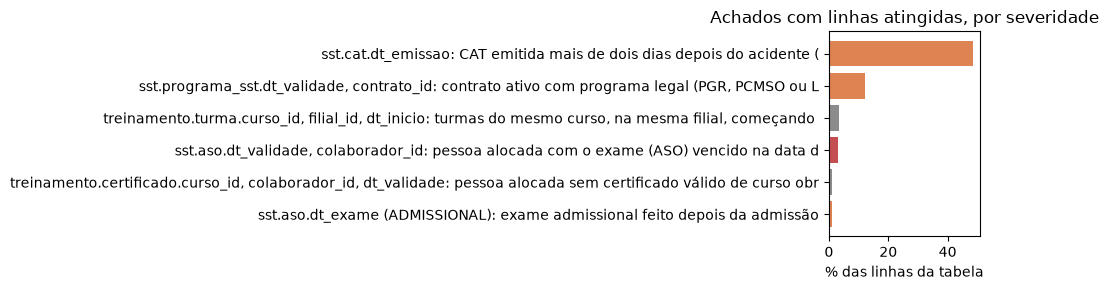

registro gravado em dados/auditoria/treinamento_sst.json


In [20]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 11 tabelas dos módulos `treinamento` e `sst`, 90 colunas e 86.338 linhas vivas, na carga identificada na seção 2: tipo, completude e coerência, unicidade, domínios, validade derivada e faixas, cronologia, integridade referencial e a declaração do cliente medida como prevalência mensal.

**O veredicto: o dado é coerente e o prazo é que não é cumprido.** Validade, faixas, referências e as relações entre acidente, afastamento e CAT passaram inteiras. Os achados são todos de prazo: 25 pessoas em campo com ASO vencido hoje, com prevalência subindo de zero a 4% em oito anos (alta, declaração confirmada); 5 contratos ativos com programa legal vencido, 155 admissionais feitos depois da admissão e 48 CATs fora do prazo (médias); 17 exigências de curso obrigatório sem certificado e 192 turmas possivelmente duplicadas (baixas). Um registro de severidade nenhuma: a validade derivada bate em 100% dos certificados e exames.

**Próximos passos:** `seguranca`, a trilha de quem fez o quê, e depois o fechamento com o confronto das seis declarações.